In [1]:
import numpy as np
import pandas as pd

In [2]:
d30_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_30bins/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
d30_fold0["fold"] = [0 for i in range(len(d30_fold0))]
d30_fold0["dist"] = [30.0 for i in range(len(d30_fold0))]

In [3]:
d30_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_30bins/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
d30_fold1["fold"] = [1 for i in range(len(d30_fold1))]
d30_fold1["dist"] = [30.0 for i in range(len(d30_fold1))]

In [4]:
d30_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_30bins/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
d30_fold2["fold"] = [2 for i in range(len(d30_fold2))]
d30_fold2["dist"] = [30.0 for i in range(len(d30_fold2))]

In [5]:
d50_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_50bins/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
d50_fold0["fold"] = [0 for i in range(len(d50_fold0))]
d50_fold0["dist"] = [50.0 for i in range(len(d50_fold0))]

In [6]:
d50_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_50bins/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
d50_fold1["fold"] = [1 for i in range(len(d50_fold1))]
d50_fold1["dist"] = [50.0 for i in range(len(d50_fold1))]

In [7]:
d50_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_50bins/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
d50_fold2["fold"] = [2 for i in range(len(d50_fold2))]
d50_fold2["dist"] = [50.0 for i in range(len(d50_fold2))]

In [8]:
d70_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_70bins/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
d70_fold0["fold"] = [0 for i in range(len(d70_fold0))]
d70_fold0["dist"] = [70.0 for i in range(len(d70_fold0))]

In [9]:
d70_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_70bins/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
d70_fold1["fold"] = [1 for i in range(len(d70_fold1))]
d70_fold1["dist"] = [70.0 for i in range(len(d70_fold1))]

In [10]:
d70_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_70bins/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
d70_fold2["fold"] = [2 for i in range(len(d70_fold2))]
d70_fold2["dist"] = [70.0 for i in range(len(d70_fold2))]

In [11]:
d90_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_90bins/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
d90_fold0["fold"] = [0 for i in range(len(d90_fold0))]
d90_fold0["dist"] = [90.0 for i in range(len(d90_fold0))]

In [12]:
d90_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_90bins/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
d90_fold1["fold"] = [1 for i in range(len(d90_fold1))]
d90_fold1["dist"] = [90.0 for i in range(len(d90_fold1))]

In [13]:
d90_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_90bins/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
d90_fold2["fold"] = [2 for i in range(len(d90_fold2))]
d90_fold2["dist"] = [90.0 for i in range(len(d90_fold2))]

In [14]:
df = pd.concat([d30_fold0, d30_fold1, d30_fold2,
                d50_fold0, d50_fold1, d50_fold2,
                d70_fold0, d70_fold1, d70_fold2,
                d90_fold0, d90_fold1, d90_fold2], ignore_index=True)

In [15]:
# summing edits together
df["num_edits"] = df["num_edits_slice0"] + df["num_edits_slice1"]

In [16]:
# optimizations with no edits
counts = df.groupby("dist")["num_edits"].apply(lambda x: (x == 0).sum())
print(counts)

dist
30.0    76
50.0    21
70.0    12
90.0     9
Name: num_edits, dtype: int64


In [17]:
# eliminating them
df = df[df["num_edits"] > 0]

In [18]:
# optimizations with edits but not sufficent dot score
dot_counts = df.groupby("dist")["dot7_result"].apply(lambda x: (x <= 0.0).sum())
print(dot_counts)

dist
30.0    1
50.0    0
70.0    0
90.0    0
Name: dot7_result, dtype: int64


In [20]:
# eliminating them
df = df[df["dot7_result"] > 0.0]

In [21]:
# successful optimizations only, average number of edits
avg_num_edits = df.groupby("dist")["num_edits"].mean()
print(avg_num_edits)

dist
30.0    217.505747
50.0    107.517483
70.0    107.664474
90.0    111.612903
Name: num_edits, dtype: float64


In [22]:
# successful optimizations only, average index with last accepted edits
avg_last_index = df.groupby("dist")["last_accepted_step"].mean()
print(avg_last_index)

dist
30.0    1251.413793
50.0    1010.692308
70.0     716.032895
90.0     700.922581
Name: last_accepted_step, dtype: float64


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
natural_results_path = "/scratch1/smaruj/natural_dots/filtered_dots_results.tsv"
nat_df = pd.read_csv(natural_results_path, sep="\t")

In [25]:
nat_df

,chrom,BIN1_START,BIN1_END,BIN2_START,BIN2_END,FDR,DETECTION_SCALE,window_start,window_end,anchor2_center_bin,anchors_dist,anchor1_center_bin,dot_strength
0,chr1,91970000,91980000,92450000,92460000,0.011590,2.111213,91536592,92847312,384,234,150,0.547183
1,chr1,91970000,91980000,92610000,92620000,0.036990,2.599208,91696592,93007312,384,312,72,0.508047
2,chr1,92160000,92170000,92450000,92460000,0.038089,2.111213,91536592,92847312,384,141,243,0.153592
3,chr1,92490000,92500000,92610000,92620000,0.017336,3.200000,91696592,93007312,384,58,326,0.405669
4,chr1,92680000,92690000,92850000,92860000,0.009500,4.222425,91936592,93247312,384,83,301,0.660956
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6813,chr19,36140000,36150000,36440000,36450000,0.013890,6.400000,35526592,36837312,384,146,238,0.802921
6814,chr19,36180000,36190000,36430000,36440000,0.000199,2.111213,35516592,36827312,384,122,262,1.466857
6815,chr19,37050000,37060000,37260000,37270000,0.030770,2.111213,36346592,37657312,384,102,282,0.997232
6816,chr19,37550000,37560000,37930000,37940000,0.037086,2.599208,37016592,38327312,384,185,199,0.444799


In [26]:
df["dot7_diff"] = df["dot7_result"] - df["dot7_init"]
df["dot11_diff"] = df["dot11_result"] - df["dot11_init"]
df["dot15_diff"] = df["dot15_result"] - df["dot15_init"]

In [27]:
df["CTCFs_num"] = df["CTCFs_num_slice0"] + df["CTCFs_num_slice1"]

In [28]:
df["FIMO_sum"] = df["FIMO_sum_slice0"] + df["FIMO_sum_slice1"]

In [29]:
df["FIMO_max"] = df[["FIMO_max_slice0", "FIMO_max_slice1"]].max(axis=1)

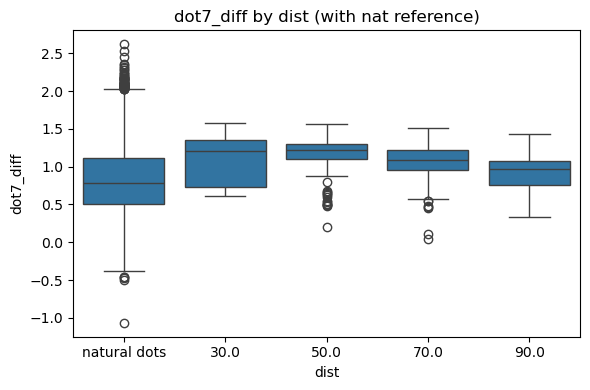

In [30]:
nat_df_box = pd.DataFrame({
    "dist": ["natural dots"] * len(nat_df),
    "dot7_diff": nat_df["dot_strength"]
})

plot_df = pd.concat([
    df[["dist", "dot7_diff"]],
    nat_df_box
], ignore_index=True)

order = ["natural dots"] + sorted(df["dist"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=plot_df, x="dist", y="dot7_diff", order=order)

plt.xlabel("dist")
plt.ylabel("dot7_diff")
plt.title("dot7_diff by dist (with nat reference)")
plt.tight_layout()
plt.show()

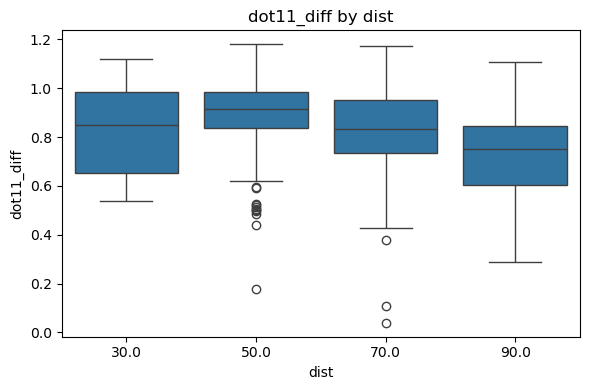

In [31]:
order = sorted(df["dist"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="dot11_diff", order=order)
plt.xlabel("dist")
plt.ylabel("dot11_diff")
plt.title("dot11_diff by dist")
plt.tight_layout()
plt.show()

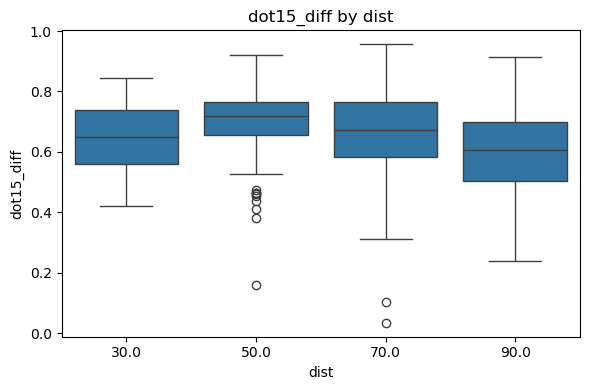

In [32]:
order = sorted(df["dist"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="dot15_diff", order=order)
plt.xlabel("dist")
plt.ylabel("dot15_diff")
plt.title("dot15_diff by dist")
plt.tight_layout()
plt.show()

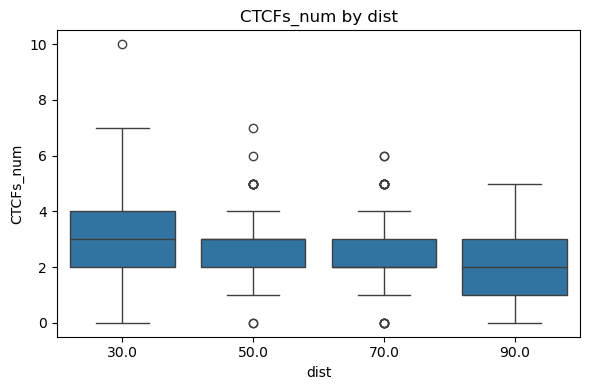

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="CTCFs_num", order=order)
plt.xlabel("dist")
plt.ylabel("CTCFs_num")
plt.title("CTCFs_num by dist")
plt.tight_layout()
plt.show()

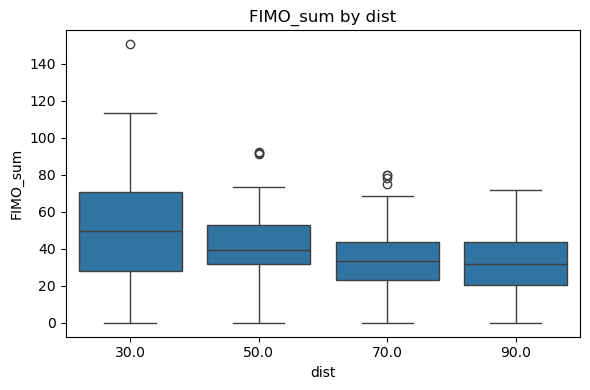

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="FIMO_sum", order=order)
plt.xlabel("dist")
plt.ylabel("FIMO_sum")
plt.title("FIMO_sum by dist")
plt.tight_layout()
plt.show()

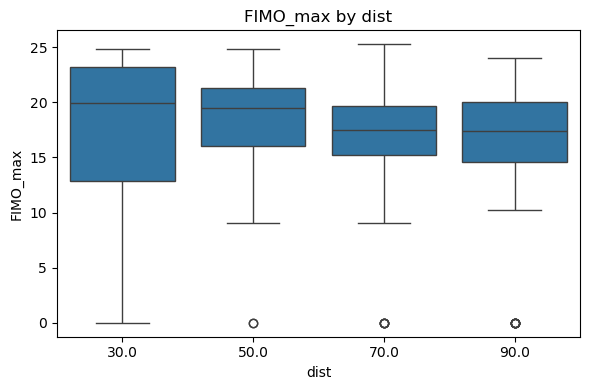

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="FIMO_max", order=order)
plt.xlabel("dist")
plt.ylabel("FIMO_max")
plt.title("FIMO_max by dist")
plt.tight_layout()
plt.show()

### Orientation

In [36]:
def combine_orientation(row):
    o0, o1 = row["orientation_slice0"], row["orientation_slice1"]
    if o0 == "no" and o1 == "no":
        return "no"
    parts = [o for o in [o0, o1] if o != "no"]
    return "".join(parts)


In [37]:
df["orientation"] = df.apply(combine_orientation, axis=1)

In [38]:
def canonicalize(ori):
    # Flip strand = replace + <-> -
    flipped = ori.replace("+", "x").replace("-", "+").replace("x", "-")
    # Pick lexicographically smaller string as canonical
    return min(ori, flipped)

In [39]:
df["orientation_canonical"] = df["orientation"].apply(canonicalize)

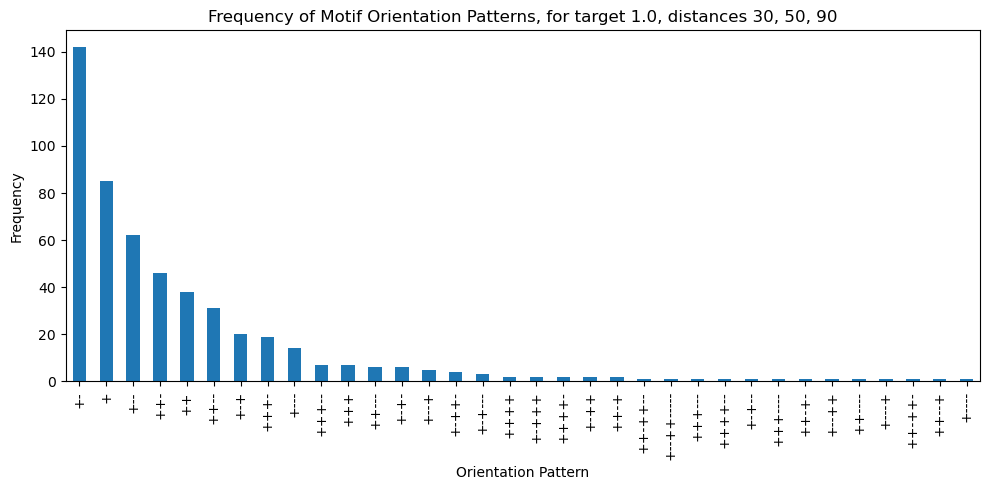

In [40]:
orientation_counts = df[df['orientation'] != "no"]['orientation_canonical'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 1.0, distances 30, 50, 90")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

How to not loose information on where the CTCFs are (which anchor)?

In [41]:
df["orientation_slice0"]

2      ++-
3      +++
10       +
11      ++
15     +-+
      ... 
651      +
652      +
653     ++
654      +
655     no
Name: orientation_slice0, Length: 537, dtype: object

In [42]:
def categorize_orientation_string(s):
    if s == "no":
        return "no CTCF"
    elif "+" in s:
        return ">1 CTCF with +"
    elif "-" in s:
        return ">1 CTCF with -"
    else:
        return "no CTCF"

df["cat_slice0"] = df["orientation_slice0"].apply(categorize_orientation_string)
df["cat_slice1"] = df["orientation_slice1"].apply(categorize_orientation_string)

In [43]:
categories = [">1 CTCF with +", ">1 CTCF with -", "no CTCF"]
contingency_table = pd.crosstab(df["cat_slice1"], df["cat_slice0"]).reindex(index=categories, columns=categories, fill_value=0)

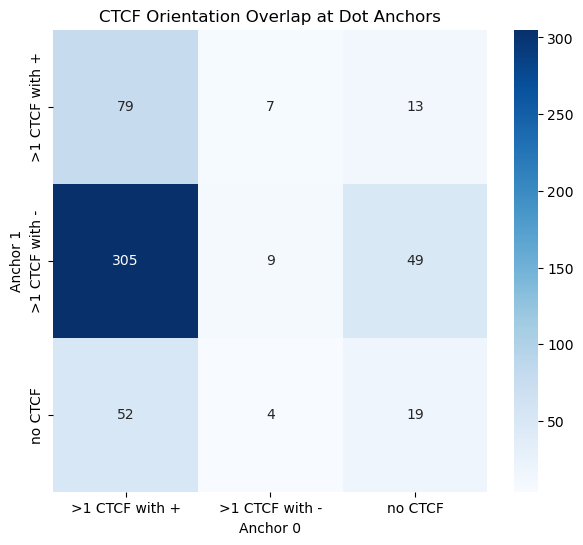

In [44]:
plt.figure(figsize=(7,6))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Anchor 0")
plt.ylabel("Anchor 1")
plt.title("CTCF Orientation Overlap at Dot Anchors")
plt.show()